# GAN

In [42]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.utils import save_image, make_grid

from utils import DeepFakeDataset, dcganFormat  # <-- your utils module

## Config

In [43]:
# =========================================================
# Config
# =========================================================
# REAL_DIR = "../../deepfake_data/wiki"
REAL_DIR = "../deepfake_data/wiki"
OUTPUT_DIR = "outputs"
SAMPLES_DIR = os.path.join(OUTPUT_DIR, "samples")
CHECKPOINTS_DIR = os.path.join(OUTPUT_DIR, "checkpoints")

IMAGE_SIZE = 64
BATCH_SIZE = 64
LATENT_DIM = 100    # Tamanho do vetor aleatório que entra no gerador
NGF = 64    # Número base de filtros do gerador
NDF = 64    # Número base de filtros do discriminador
NUM_CHANNELS = 3    # 3 channels porque estou a usar RGB

# Parametros de treino
NUM_EPOCHS = 200 # TODO: changed to 200 for testing
LR_G = 2e-4     # Learning rate do gerador
LR_D = 1e-4     # Learning rate do discriminador
BETA1 = 0.5     # Hiperparametro do Adam (é um valor clássico em DCGAN)
SEED = 42
NUM_WORKERS = 2     # Número de workers no DataLoader

# Que folds usar
START_FOLD = 0
END_FOLD = 5
INTERVAL = True

# Usar CUDA para ser mais rápido
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"

# Crias as pastas dos outputs
os.makedirs(SAMPLES_DIR, exist_ok=True)
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

# Torna o treino mais consistente entre execuções
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)

Device: cuda


## Utils

In [44]:
import json, base64, io
from PIL import Image as PILImage

def save_samples_jsonl(epoch, generator, noise, path, nrow=8):
    """Append one lossless-PNG sample grid (base64) as a JSON line."""
    generator.eval()
    with torch.no_grad():
        fake = generator(noise).detach().cpu()
        fake = (fake + 1) / 2                               # [-1,1] -> [0,1]
        grid = make_grid(fake, nrow=nrow, padding=2, normalize=False)
        arr = (grid.permute(1, 2, 0).numpy() * 255).clip(0, 255).astype("uint8")
        buf = io.BytesIO()
        PILImage.fromarray(arr).save(buf, format="PNG", optimize=True)
        b64 = base64.b64encode(buf.getvalue()).decode("ascii")
    generator.train()

    with open(path, "a") as f:
        f.write(json.dumps({"epoch": epoch, "format": "png", "grid_b64": b64}) + "\n")

## Dataset & DataLoader

In [45]:
dataset = DeepFakeDataset(
    img_dir=REAL_DIR,
    label=1,                           # ignored; image_only=True
    transform=dcganFormat(IMAGE_SIZE),
    range_folds=[START_FOLD, END_FOLD],
    interval=INTERVAL,
    image_only=True,                   # GAN mode: return only image tensor
)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0, # TODO: changed to 0 for debugging
    pin_memory=PIN_MEMORY,
    drop_last=True,
)

print(f"Total de imagens reais: {len(dataset)}")
print(f"Folds usados: {dataset.fold_names}")

Building ../deepfake_data/wiki dataset with 5 folds: 100%|██████████| 5/5 [00:00<00:00, 624.93it/s]

Total de imagens reais: 1467
Folds usados: ['00', '01', '02', '03', '04']


### Ver uma imagem do dataset

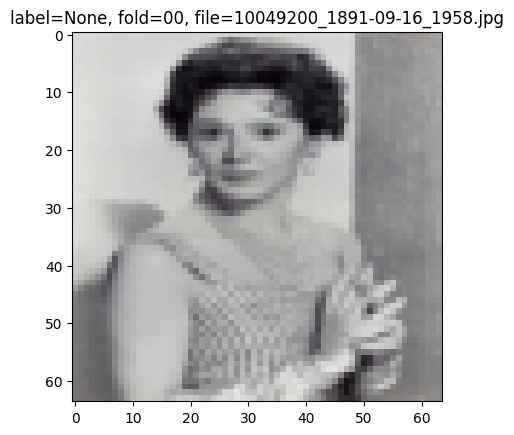

img_shape=torch.Size([3, 64, 64]), img_type=<class 'torch.Tensor'>, label=None, fold=00, file=10049200_1891-09-16_1958.jpg


tensor([[[ 0.7098,  0.7098,  0.7020,  ...,  0.2235,  0.3020,  0.3333],
         [ 0.7098,  0.7020,  0.6941,  ...,  0.2392,  0.2471,  0.2863],
         [ 0.6941,  0.7020,  0.6784,  ...,  0.2471,  0.2157,  0.2314],
         ...,
         [-0.0745, -0.0902, -0.1373,  ...,  0.0431,  0.0667,  0.0824],
         [-0.0824, -0.1059, -0.1451,  ...,  0.0745,  0.1137,  0.1137],
         [-0.0667, -0.0980, -0.1216,  ...,  0.1137,  0.1216,  0.1137]],

        [[ 0.7176,  0.7176,  0.7020,  ...,  0.2000,  0.2706,  0.3020],
         [ 0.7176,  0.7098,  0.6941,  ...,  0.2157,  0.2235,  0.2627],
         [ 0.6941,  0.7020,  0.6863,  ...,  0.2471,  0.2157,  0.2235],
         ...,
         [-0.0980, -0.1216, -0.1686,  ...,  0.0196,  0.0353,  0.0510],
         [-0.1059, -0.1294, -0.1608,  ...,  0.0431,  0.0824,  0.0824],
         [-0.0980, -0.1216, -0.1451,  ...,  0.0824,  0.0902,  0.0824]],

        [[ 0.6784,  0.6784,  0.6784,  ...,  0.1765,  0.2471,  0.2784],
         [ 0.6863,  0.6784,  0.6706,  ...,  0

In [46]:
dataset.show(0)

### Inicialização de pesos

In [47]:
# Esta função inicializa os pesos da rede, se for:
# - Camada convolucional: inicializa os pesos com distribuição normal (média 0 e desvio padrão 0.02)
# - Camada BatchNorm: pesos perto de 1 e bias 0 
def weights_init(m):
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)
# Isto é o tipo de inicialização clássica em DCGAN

# Gerador

In [48]:
# O Gerador recebe um vetor aleatório z e tenta convertê-lo numa imagem falsa realista
class Generator(nn.Module):
    def __init__(self, latent_dim=100, ngf=64, nc=3):
        super().__init__()

        self.init = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
        )

        self.main = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(ngf * 8, ngf * 4, 3, 1, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(ngf * 4, ngf * 2, 3, 1, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(ngf * 2, ngf, 3, 1, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(ngf, nc, 3, 1, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.init(z)
        return self.main(x)

# Discriminador

In [49]:
# Recebe uma imagem e tenta dizer se ela é real ou falsa
# Ele faz o oposto do gerador, reduz progressivamente a resolução, aumentando profundidade e no fim produz um único valor por imagem
class Discriminator(nn.Module):
    def __init__(self, nc=3, ndf=64):
        super().__init__()
        self.main = nn.Sequential(
            # 64x64 -> 32x32
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # 32x32 -> 16x16
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # 16x16 -> 8x8
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # 8x8 -> 4x4
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            # 4x4 -> 1x1
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False)
        )

    def forward(self, x):
        return self.main(x).view(-1)

# Instanciar modelos

In [50]:
netG = Generator(LATENT_DIM, NGF, NUM_CHANNELS).to(DEVICE)
netD = Discriminator(NUM_CHANNELS, NDF).to(DEVICE)

netG.apply(weights_init)
netD.apply(weights_init)

print(netG)
print(netD)

Generator(
  (init): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (main): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU(inplace=True)
    (4): Upsample(scale_factor=2.0, mode='nearest')
    (5): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): Upsample(scale_factor=2.0, mode='nearest')
    (9): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats

In [51]:
# Loss binária com logits
# O discriminador devolve logits crus, sem sigmoid, esta loss combina sigmoid e binary cross entropy de forma mais estavel numericamente
criterion = nn.BCEWithLogitsLoss()

# Otimizadores Adam para o discriminador e o gerador
optimizerD = optim.Adam(netD.parameters(), lr=LR_D, betas=(BETA1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=LR_G, betas=(BETA1, 0.999))

# Ruido fixo para as amostras. Este ruido serve para gerar sempre as mesmas 64 imagens ao longo do treino.
# Deste modo podemos ver a evolução do gerador de forma consistente (na epoch 1, 10, 50, etc)
fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=DEVICE)

## Função para guardar amostras

In [52]:
def save_generated_samples(epoch, generator, noise):
    generator.eval()
    with torch.no_grad():
        fake_images = generator(noise).detach().cpu()
        fake_images = (fake_images + 1) / 2  # [-1,1] -> [0,1]
        grid = make_grid(fake_images, nrow=8, padding=2, normalize=False)
        save_image(grid, os.path.join(SAMPLES_DIR, f"epoch_{epoch:03d}.png"))
    generator.train()

## Treino

Saving this code...


---

```py

# ---- Split sample output across N files (for GitHub 100MB limit) ----
NUM_SPLITS = 3
EPOCHS_PER_SPLIT = math.ceil(NUM_EPOCHS / NUM_SPLITS)
SAMPLE_FILES = [
    os.path.join(OUTPUT_DIR, f"samples_{k+1:02d}.jsonl")
    for k in range(NUM_SPLITS)
]
for p in SAMPLE_FILES: open(p, "w").close()   # truncate any previous run

def sample_file_for(epoch):
    return SAMPLE_FILES[min((epoch - 1) // EPOCHS_PER_SPLIT, NUM_SPLITS - 1)]


```


---

In [ ]:
from tqdm.auto import tqdm
import pandas as pd
import math

# ---- Calibrate & split sample output to ~90 MB files ----
import io, base64, json
from PIL import Image as PILImage

TARGET_MB = 90                                  # middle of [89, 92] MB range (safe)
TARGET_BYTES = TARGET_MB * 1024 * 1024

def _sample_line_bytes(generator, noise, nrow=8):
    """Produce one frame exactly as save_samples_jsonl would, return its JSONL line size in bytes."""
    generator.eval()
    with torch.no_grad():
        fake = generator(noise).detach().cpu()
        fake = (fake + 1) / 2
        grid = make_grid(fake, nrow=nrow, padding=2, normalize=False)
        arr = (grid.permute(1, 2, 0).numpy() * 255).clip(0, 255).astype("uint8")
        buf = io.BytesIO()
        PILImage.fromarray(arr).save(buf, format="PNG", optimize=True)
        b64 = base64.b64encode(buf.getvalue()).decode("ascii")
    generator.train()
    line = json.dumps({"epoch": 0, "format": "png", "grid_b64": b64}) + "\n"
    return len(line.encode("utf-8"))

frame_bytes = _sample_line_bytes(netG, fixed_noise)
total_bytes = frame_bytes * NUM_EPOCHS

EPOCHS_PER_SPLIT = max(1, TARGET_BYTES // frame_bytes)
NUM_SPLITS = math.ceil(NUM_EPOCHS / EPOCHS_PER_SPLIT)
last_epochs = NUM_EPOCHS - (NUM_SPLITS - 1) * EPOCHS_PER_SPLIT

full_mb = (EPOCHS_PER_SPLIT * frame_bytes) / (1024 * 1024)
last_mb = (last_epochs * frame_bytes) / (1024 * 1024)

print("Sample-file calibration")
print(f"  frame size:       ~{frame_bytes/1024:>7.1f} KB")
print(f"  projected total:  ~{total_bytes/1024/1024:>7.1f} MB  ({NUM_EPOCHS} epochs)")
print(f"  → {NUM_SPLITS} files: {NUM_SPLITS-1} × ~{full_mb:.1f} MB + 1 × ~{last_mb:.1f} MB")

SAMPLE_FILES = [
    os.path.join(OUTPUT_DIR, f"samples_{k+1:02d}.jsonl")
    for k in range(NUM_SPLITS)
]
for p in SAMPLE_FILES: open(p, "w").close()      # truncate any previous run

def sample_file_for(epoch):
    return SAMPLE_FILES[min((epoch - 1) // EPOCHS_PER_SPLIT, NUM_SPLITS - 1)]

# -----------------------

history, g_losses, d_losses = [], [], []
print("A começar treino...")

epoch_bar = tqdm(range(1, NUM_EPOCHS + 1), desc="Training", unit="epoch")
for epoch in epoch_bar:
    epoch_g_loss = epoch_d_loss = 0.0
    epoch_dx = epoch_dgz_fake = epoch_dgz_gen = 0.0

    batch_bar = tqdm(dataloader, desc=f"Epoch {epoch}", leave=False, unit="batch")
    for real_images in batch_bar:
        real_images = real_images.to(DEVICE)
        b_size = real_images.size(0)

        # --- Discriminator ---
        netD.zero_grad(set_to_none=True)
        output_real = netD(real_images)
        lossD_real = criterion(output_real, torch.ones(b_size, device=DEVICE))

        noise = torch.randn(b_size, LATENT_DIM, 1, 1, device=DEVICE)
        fake_images = netG(noise)
        output_fake = netD(fake_images.detach())
        lossD_fake = criterion(output_fake, torch.zeros(b_size, device=DEVICE))

        lossD = lossD_real + lossD_fake
        lossD.backward()
        optimizerD.step()

        # --- Generator ---
        netG.zero_grad(set_to_none=True)
        output_gen = netD(fake_images)
        lossG = criterion(output_gen, torch.ones(b_size, device=DEVICE))
        lossG.backward()
        optimizerG.step()

        epoch_d_loss += lossD.item()
        epoch_g_loss += lossG.item()
        epoch_dx += torch.sigmoid(output_real).mean().item()
        epoch_dgz_fake += torch.sigmoid(output_fake).mean().item()
        epoch_dgz_gen += torch.sigmoid(output_gen).mean().item()

        batch_bar.set_postfix(
            d=f"{lossD.item():.3f}", g=f"{lossG.item():.3f}",
            dx=f"{torch.sigmoid(output_real).mean().item():.2f}",
        )

    n = len(dataloader)
    avg_d, avg_g = epoch_d_loss / n, epoch_g_loss / n
    avg_dx = epoch_dx / n
    avg_dgz_fake, avg_dgz_gen = epoch_dgz_fake / n, epoch_dgz_gen / n

    d_losses.append(avg_d); g_losses.append(avg_g)
    history.append({
        "epoch": epoch, "loss_d": avg_d, "loss_g": avg_g,
        "D_x": avg_dx, "D_G_z_fake": avg_dgz_fake, "D_G_z_gen": avg_dgz_gen,
    })

    epoch_bar.set_postfix(
        loss_d=f"{avg_d:.3f}", loss_g=f"{avg_g:.3f}",
        d_x=f"{avg_dx:.2f}", dgz=f"{avg_dgz_gen:.2f}",
    )

    # Save a frame every epoch into the current split file
    for _ in tqdm([0], desc=f"Saving epoch {epoch}", leave=False):
        save_samples_jsonl(epoch, netG, fixed_noise, sample_file_for(epoch))

    pd.DataFrame(history).to_csv(os.path.join(OUTPUT_DIR, "training_history.csv"), index=False)
    torch.save({
        "epoch": epoch,
        "netG_state_dict": netG.state_dict(),
        "netD_state_dict": netD.state_dict(),
        "optimizerG_state_dict": optimizerG.state_dict(),
        "optimizerD_state_dict": optimizerD.state_dict(),
        "g_losses": g_losses, "d_losses": d_losses, "history": history,
        "folds_used": dataset.fold_names, "real_dir": REAL_DIR,
    }, os.path.join(CHECKPOINTS_DIR, f"dcgan_epoch_{epoch:03d}.pt"))

print("Treino terminado.")
print("Sample files:", SAMPLE_FILES)

A começar treino...


Training: 100%|██████████| 200/200 [16:27<00:00,  4.94s/epoch, d_x=0.98, dgz=0.01, loss_d=0.036, loss_g=4.854]

Treino terminado.
Sample files: ['outputs\\samples_01.jsonl', 'outputs\\samples_02.jsonl', 'outputs\\samples_03.jsonl']


In [55]:
print("CUDA available:", torch.cuda.is_available())
print("netG on:", next(netG.parameters()).device)
print("netD on:", next(netD.parameters()).device)

CUDA available: True
netG on: cuda:0
netD on: cuda:0


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x00000253E7217920>
Traceback (most recent call last):
  File "c:\Users\hasht\anaconda3\envs\adversarial\Lib\site-packages\torch\utils\data\dataloader.py", line 1663, in __del__
    self._shutdown_workers()
  File "c:\Users\hasht\anaconda3\envs\adversarial\Lib\site-packages\torch\utils\data\dataloader.py", line 1627, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "c:\Users\hasht\anaconda3\envs\adversarial\Lib\multiprocessing\process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\hasht\anaconda3\envs\adversarial\Lib\multiprocessing\popen_spawn_win32.py", line 112, in wait
    res = _winapi.WaitForSingleObject(int(self._handle), msecs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt: 


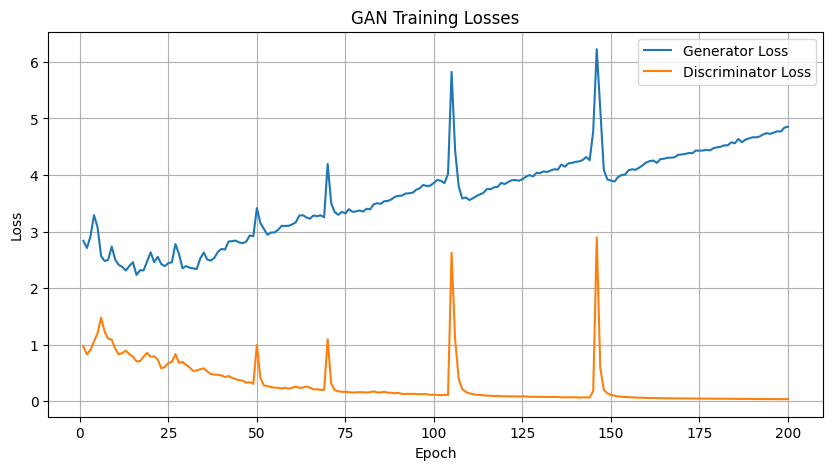

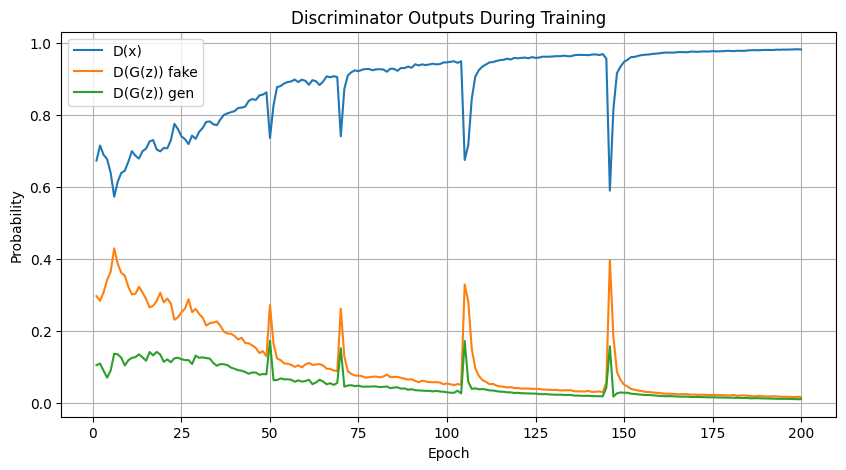

In [56]:
import os
import pandas as pd
import matplotlib.pyplot as plt

history_path = os.path.join(OUTPUT_DIR, "training_history.csv")
history_df = pd.read_csv(history_path)

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["loss_g"], label="Generator Loss")
plt.plot(history_df["epoch"], history_df["loss_d"], label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Losses")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["D_x"], label="D(x)")
plt.plot(history_df["epoch"], history_df["D_G_z_fake"], label="D(G(z)) fake")
plt.plot(history_df["epoch"], history_df["D_G_z_gen"], label="D(G(z)) gen")
plt.xlabel("Epoch")
plt.ylabel("Probability")
plt.title("Discriminator Outputs During Training")
plt.legend()
plt.grid(True)
plt.show()

Como o D devolve logits, aplicas sigmoid para obter algo parecido com probabilidade.

- `D(x):` Probabilidade média atribuída às imagens reais. (idealmente alta)

- `D(G(z)) fake:` Probabilidade média atribuída às falsas quando treinas o D. (idealmente baixa)

- `D(G(z)) gen:` Probabilidade média atribuída às falsas quando observadas no passo do G. (se começar a subir, pode indicar que o G está a enganar melhor o D)

# Gerar imagens a partir do último modelo em memória

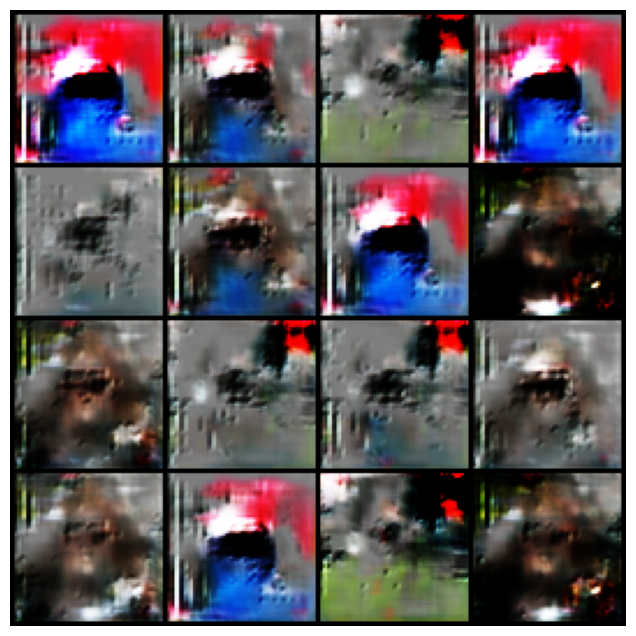

In [ ]:
netG.eval()
with torch.no_grad():
    noise = torch.randn(16, LATENT_DIM, 1, 1, device=DEVICE)
    fake_images = netG(noise).cpu()
    fake_images = (fake_images + 1) / 2

grid = make_grid(fake_images, nrow=4, padding=2)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

# Confirmar que os dados estão bem:

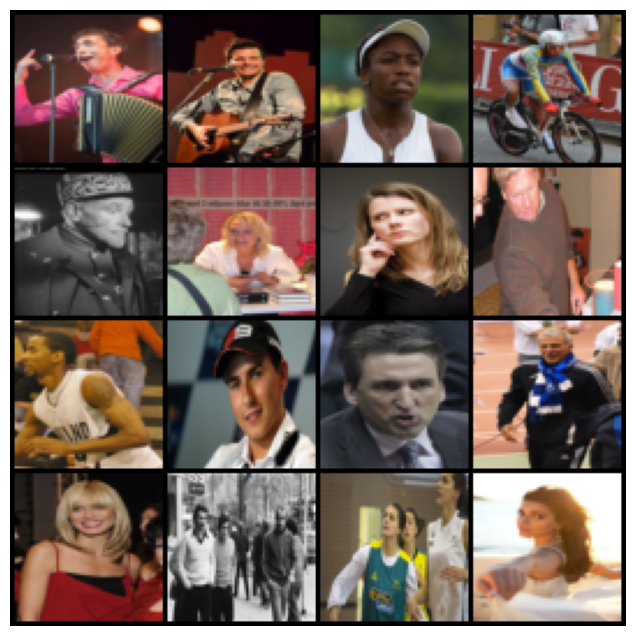

In [ ]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

real_batch = next(iter(dataloader))
real_batch = real_batch[:16].cpu()
real_batch = (real_batch + 1) / 2  # volta de [-1,1] para [0,1]

grid = make_grid(real_batch, nrow=4, padding=2)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

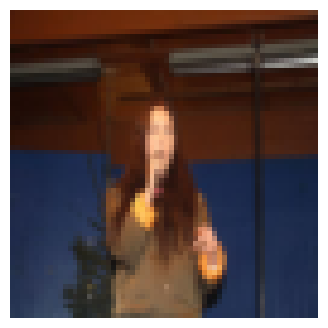

In [ ]:
real_batch = next(iter(dataloader))
img = real_batch[0].cpu()
img = (img + 1) / 2  # [-1,1] -> [0,1]

import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))
plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.show()